<a href="https://colab.research.google.com/github/JavierAMLC/Laboratorio_UCV_CNN_Digitos_UCI-/blob/main/Laboratorio_UCV_CNN_Con_Descripciones.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# UNIVERSIDAD CÉSAR VALLEJO
## Escuela Profesional de Ingeniería de Sistemas
### Curso: Sistemas Inteligentes

**LABORATORIO COMPLETO:** Clasificación de dígitos escritos a mano usando CNN (UCI Machine Learning Repository)

In [1]:
%pip install ucimlrepo tensorflow pandas numpy matplotlib scikit-learn -q


## 1. Importar Librerías y Configuración del Entorno

**Descripción de funciones clave:**
- `fetch_ucirepo`: Permite descargar datasets directamente desde el repositorio oficial de la UCI usando su ID técnico.
- `Sequential`: API de Keras para construir modelos capa por capa de forma lineal.
- `to_categorical`: Convierte vectores de etiquetas enteras en una matriz de clases binarias (codificación One-Hot).

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from ucimlrepo import fetch_ucirepo

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, ConfusionMatrixDisplay

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.utils import to_categorical

tf.random.set_seed(42)
np.random.seed(42)

print('TensorFlow Versión:', tf.__version__)

TensorFlow Versión: 2.20.0


## 2. Cargar Dataset Real desde UCI (ID: 80)

**Descripción de funciones clave:**
- `fetch_ucirepo(id=80)`: Descarga el conjunto de datos 'Optical Recognition of Handwritten Digits'.
- `digits.data.features`: Extrae la matriz de características distribuidas en columnas de píxeles.
- `digits.data.targets.squeeze()`: Extrae las etiquetas correspondientes reduciendo dimensiones innecesarias.

In [3]:
digits = fetch_ucirepo(id=80)

X = digits.data.features
y = digits.data.targets.squeeze()

print('Dimensión de variables independientes (X):', X.shape)
print('Dimensión de variable objetivo (y):', y.shape)
X.head()

Dimensión de variables independientes (X): (5620, 64)
Dimensión de variable objetivo (y): (5620,)


,Attribute1,Attribute2,Attribute3,Attribute4,Attribute5,Attribute6,Attribute7,Attribute8,Attribute9,Attribute10,...,Attribute55,Attribute56,Attribute57,Attribute58,Attribute59,Attribute60,Attribute61,Attribute62,Attribute63,Attribute64
0,0,1,6,15,12,1,0,0,0,7,...,0,0,0,0,6,14,7,1,0,0
1,0,0,10,16,6,0,0,0,0,7,...,3,0,0,0,10,16,15,3,0,0
2,0,0,8,15,16,13,0,0,0,1,...,0,0,0,0,9,14,0,0,0,0
3,0,0,0,3,11,16,0,0,0,0,...,0,0,0,0,0,1,15,2,0,0
4,0,0,5,14,4,0,0,0,0,0,...,12,0,0,0,4,12,14,7,0,0


## 3. Preprocesamiento: Convertir Datos a Formato de Imagen (8x8x1)

**Descripción de funciones clave:**
- `reshape(-1, 8, 8, 1)`: Reestructura el vector plano de 64 elementos en una matriz bidimensional de 8x8 con 1 canal de color (escala de grises), formato mandatorio para capas convolucionales.

In [4]:
X_images = X.to_numpy().reshape(-1, 8, 8, 1)
y_values = y.to_numpy().astype('int')

print('Nueva forma tridimensional de X:', X_images.shape)
print('Forma de y:', y_values.shape)

Nueva forma tridimensional de X: (5620, 8, 8, 1)
Forma de y: (5620,)


## 4. Visualizar Ejemplos del Dataset

**Descripción de funciones clave:**
- `plt.subplot`: Divide la figura en rejillas ordenadas de filas y columnas para albergar múltiples gráficos.
- `plt.imshow(..., cmap='gray')`: Renderiza matrices numéricas bidimensionales como imágenes visuales en escala de grises.

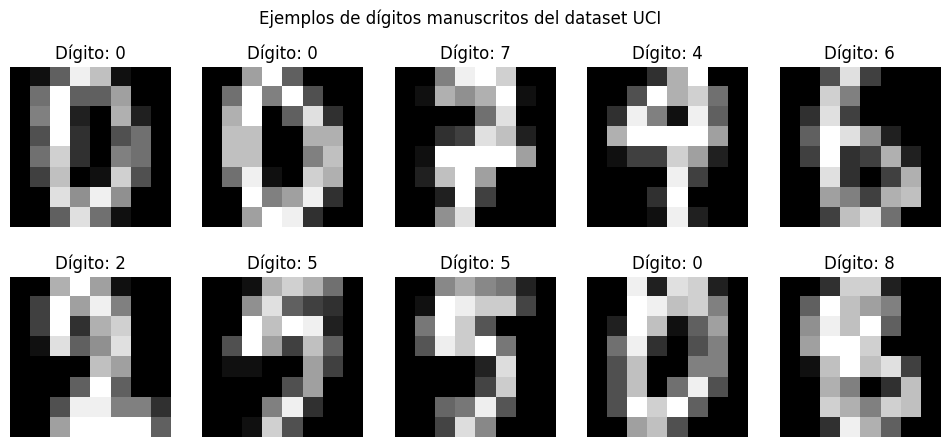

In [5]:
plt.figure(figsize=(12, 5))
for i in range(10):
    plt.subplot(2, 5, i + 1)
    plt.imshow(X_images[i].reshape(8, 8), cmap='gray')
    plt.title(f'Dígito: {y_values[i]}')
    plt.axis('off')
plt.suptitle('Ejemplos de dígitos manuscritos del dataset UCI')
plt.show()

## 5. Normalización y Codificación de Etiquetas (One-Hot)

**Descripción de funciones clave:**
- Operación `/ 16.0`: Escala linealmente los valores de los píxeles (originalmente de 0 a 16) al rango estandarizado [0, 1] para acelerar la convergencia del gradiente.

In [6]:
X_images = X_images / 16.0
num_classes = 10
y_categorical = to_categorical(y_values, num_classes=num_classes)
print('Valor mínimo transformado:', X_images.min())
print('Valor máximo transformado:', X_images.max())

Valor mínimo transformado: 0.0
Valor máximo transformado: 1.0


## 6. División del Dataset en Entrenamiento y Prueba

**Descripción de funciones clave:**
- `train_test_split`: Segmenta los datos de manera aleatoria.
- Parámetro `stratify`: Garantiza que las proporciones de cada clase (dígitos del 0 al 9) se mantengan idénticas tanto en el conjunto de entrenamiento como en el de testeo.

In [7]:
X_train, X_test, y_train, y_test, y_train_labels, y_test_labels = train_test_split(
    X_images,
    y_categorical,
    y_values,
    test_size=0.30,
    random_state=42,
    stratify=y_values,
)
print('Set de entrenamiento (X):', X_train.shape)
print('Set de prueba (X):', X_test.shape)

Set de entrenamiento (X): (3934, 8, 8, 1)
Set de prueba (X): (1686, 8, 8, 1)


## 7. Arquitectura y Configuración del Modelo CNN

**Descripción de funciones clave:**
- `Conv2D`: Capa convolucional que extrae mapas de características locales mediante filtros de convolución.
- `MaxPooling2D`: Capa de submuestreo que reduce el tamaño espacial de las características, seleccionando los valores máximos.
- `Flatten`: Aplana la estructura de tensores multidimensionales a un vector unidimensional.
- `Dropout`: Técnica de regularización que apaga neuronas aleatoriamente para mitigar el sobreajuste (overfitting).
- `model.compile`: Configura los parámetros críticos de preparación como el optimizador (`adam`) y la función de pérdida (`categorical_crossentropy`).

In [8]:
model = Sequential([
    Conv2D(16, (3, 3), activation='relu', input_shape=(8, 8, 1)),
    MaxPooling2D((2, 2)),
    Conv2D(32, (2, 2), activation='relu'),
    Flatten(),
    Dense(64, activation='relu'),
    Dropout(0.2),
    Dense(10, activation='softmax')
])

model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)
model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 6, 6, 16)       │           160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 3, 3, 16)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 2, 2, 32)       │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,146 (43.54 KB)

 Trainable params: 11,146 (43.54 KB)

 Non-trainable params: 0 (0.00 B)

## 8. Entrenamiento del Modelo

**Descripción de funciones clave:**
- `model.fit`: Ejecuta los ciclos de entrenamiento iterativos (epochs) ajustando los pesos de la red.
- Parámetro `validation_split`: Reserva una fracción del set de entrenamiento para evaluar la pérdida de validación al final de cada época sin sesgar el test final.

In [9]:
history = model.fit(
    X_train,
    y_train,
    epochs=30,
    batch_size=32,
    validation_split=0.2,
    verbose=1
)

Epoch 1/30
99/99 ━━━━━━━━━━━━━━━━━━━━ 8s 34ms/step - accuracy: 0.4954 - loss: 1.8448 - val_accuracy: 0.7738 - val_loss: 0.9930
Epoch 2/30
99/99 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - accuracy: 0.8224 - loss: 0.6429 - val_accuracy: 0.9174 - val_loss: 0.3426
Epoch 3/30
99/99 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - accuracy: 0.8942 - loss: 0.3661 - val_accuracy: 0.9390 - val_loss: 0.2272
Epoch 4/30
99/99 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.9202 - loss: 0.2718 - val_accuracy: 0.9568 - val_loss: 0.1669
Epoch 5/30
99/99 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - accuracy: 0.9377 - loss: 0.2230 - val_accuracy: 0.9644 - val_loss: 0.1412
Epoch 6/30
99/99 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.9504 - loss: 0.1867 - val_accuracy: 0.9632 - val_loss: 0.1229
Epoch 7/30
99/99 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.9549 - loss: 0.1658 - val_accuracy: 0.9695 - val_loss: 0.1057
Epoch 8/30
99/99 ━━━━━━━━━━━━━━━━━━━━ 2s 16ms/step - accuracy: 0.9558 - loss: 0.1571 - val_accuracy: 0.9720 - v

## 9. Visualización de Curvas de Aprendizaje (Pérdida y Precisión)

**Descripción de funciones clave:**
- `history.history`: Diccionario que registra los valores detallados de métricas (`loss`, `accuracy`) obtenidos paso a paso durante el entrenamiento y validación.

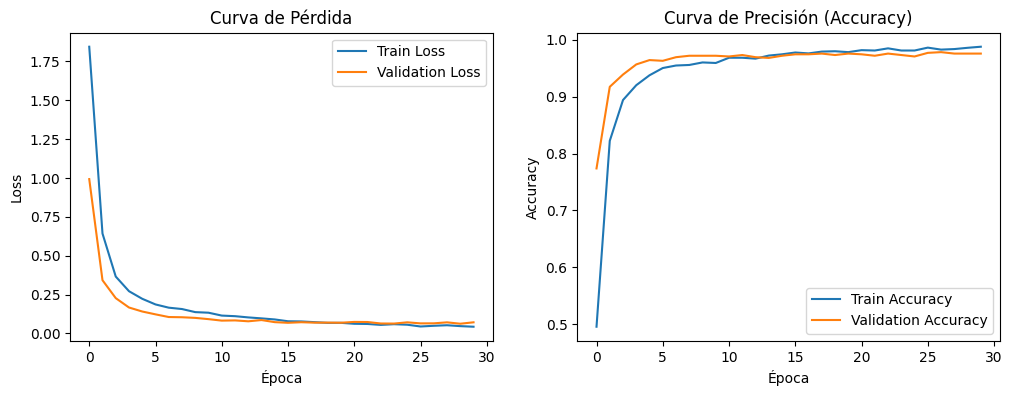

In [10]:
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Curva de Pérdida')
plt.xlabel('Época')
plt.ylabel('Loss')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Curva de Precisión (Accuracy)')
plt.xlabel('Época')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

## 10. Evaluación en Datos de Test y Matriz de Confusión Final

**Descripción de funciones clave:**
- `model.evaluate`: Calcula la pérdida y exactitud final evaluando el modelo sobre datos que nunca vio en el entrenamiento.
- `model.predict`: Genera las probabilidades de salida para cada clase.
- `np.argmax(..., axis=1)`: Selecciona el índice con la probabilidad más alta para transformarlo a una etiqueta de dígito predicha.
- `classification_report`: Genera un resumen estadístico detallado con Precision, Recall y F1-Score por cada dígito.
- `ConfusionMatrixDisplay.from_predictions`: Grafica de forma matricial los aciertos y las confusiones exactas del modelo.

Test loss : 0.0515
Test accuracy: 0.9858
53/53 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step

Reporte de Clasificación:
              precision    recall  f1-score   support

           0       0.99      1.00      1.00       166
           1       0.99      0.99      0.99       171
           2       0.99      0.98      0.99       167
           3       0.97      0.98      0.97       172
           4       0.98      1.00      0.99       171
           5       0.97      0.98      0.97       167
           6       0.99      0.99      0.99       167
           7       0.99      1.00      0.99       170
           8       1.00      0.98      0.99       166
           9       0.98      0.96      0.97       169

    accuracy                           0.99      1686
   macro avg       0.99      0.99      0.99      1686
weighted avg       0.99      0.99      0.99      1686



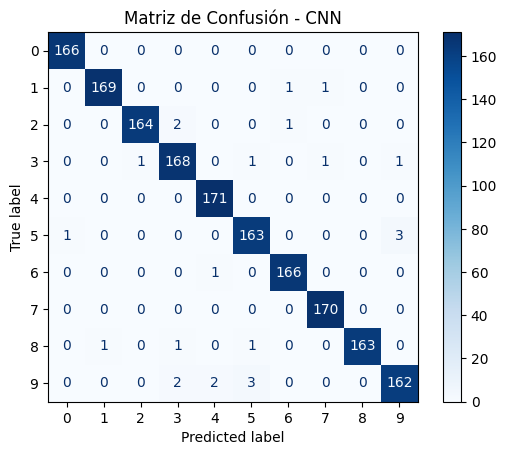

In [11]:
test_loss, test_accuracy = model.evaluate(X_test, y_test, verbose=0)
print(f'Test loss : {test_loss:.4f}')
print(f'Test accuracy: {test_accuracy:.4f}')

y_pred_prob = model.predict(X_test)
y_pred_labels = np.argmax(y_pred_prob, axis=1)

print('\nReporte de Clasificación:')
print(classification_report(y_test_labels, y_pred_labels))

ConfusionMatrixDisplay.from_predictions(
    y_test_labels,
    y_pred_labels,
    display_labels=list(range(10)),
    cmap='Blues'
)
plt.title('Matriz de Confusión - CNN')
plt.show()

##  Reto MIT: Experimentación con Variantes de Modelos CNN

Vamos a explorar tres arquitecturas diferentes de CNN y comparar su rendimiento en términos de precisión, pérdida, cantidad de errores y dígitos más confundidos.

### Variante 1: CNN Básica con Una Sola Capa Convolucional

In [12]:
model_v1 = Sequential([
    Conv2D(16, (3, 3), activation='relu', input_shape=(8, 8, 1)),
    MaxPooling2D((2, 2)),
    Flatten(),
    Dense(64, activation='relu'),
    Dropout(0.2),
    Dense(num_classes, activation='softmax')
])

model_v1.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

print('Resumen del Modelo V1 (1 Capa Conv):')
model_v1.summary()

history_v1 = model_v1.fit(
    X_train,
    y_train,
    epochs=30,
    batch_size=32,
    validation_split=0.2,
    verbose=0
)

Resumen del Modelo V1 (1 Capa Conv):


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_2 (Conv2D)               │ (None, 6, 6, 16)       │           160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 3, 3, 16)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 144)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │         9,280 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 10,090 (39.41 KB)

 Trainable params: 10,090 (39.41 KB)

 Non-trainable params: 0 (0.00 B)


Resultados Modelo V1 (1 Capa Conv):
Test loss    : 0.0501
Test accuracy: 0.9864
53/53 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step

Reporte de Clasificación Modelo V1:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       166
           1       0.99      1.00      0.99       171
           2       1.00      0.99      0.99       167
           3       0.98      0.98      0.98       172
           4       0.99      0.99      0.99       171
           5       0.98      0.98      0.98       167
           6       0.99      0.99      0.99       167
           7       0.99      0.99      0.99       170
           8       0.99      0.97      0.98       166
           9       0.95      0.98      0.96       169

    accuracy                           0.99      1686
   macro avg       0.99      0.99      0.99      1686
weighted avg       0.99      0.99      0.99      1686



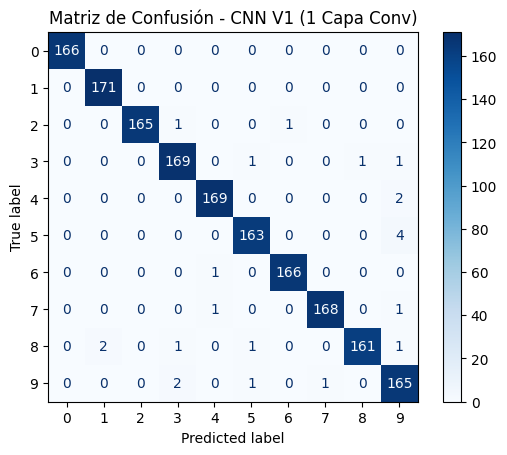

In [13]:
test_loss_v1, test_accuracy_v1 = model_v1.evaluate(X_test, y_test, verbose=0)
print(f'\nResultados Modelo V1 (1 Capa Conv):')
print(f'Test loss    : {test_loss_v1:.4f}')
print(f'Test accuracy: {test_accuracy_v1:.4f}')

y_pred_prob_v1 = model_v1.predict(X_test)
y_pred_labels_v1 = np.argmax(y_pred_prob_v1, axis=1)

print('\nReporte de Clasificación Modelo V1:')
print(classification_report(y_test_labels, y_pred_labels_v1))

ConfusionMatrixDisplay.from_predictions(
    y_test_labels,
    y_pred_labels_v1,
    display_labels=list(range(10)),
    cmap='Blues'
)
plt.title('Matriz de Confusión - CNN V1 (1 Capa Conv)')
plt.show()

### Variante 2: CNN con Dos Capas Convolucionales (Modelo Original del Laboratorio)

In [14]:
model_v2 = Sequential([
    Conv2D(16, (3, 3), activation='relu', input_shape=(8, 8, 1)),
    MaxPooling2D((2, 2)),
    Conv2D(32, (2, 2), activation='relu'),
    Flatten(),
    Dense(64, activation='relu'),
    Dropout(0.2),
    Dense(num_classes, activation='softmax')
])

model_v2.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

print('Resumen del Modelo V2 (2 Capas Conv - Modelo Original):')
model_v2.summary()

history_v2 = model_v2.fit(
    X_train,
    y_train,
    epochs=30,
    batch_size=32,
    validation_split=0.2,
    verbose=0
)

Resumen del Modelo V2 (2 Capas Conv - Modelo Original):


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)               │ (None, 6, 6, 16)       │           160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 3, 3, 16)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 2, 2, 32)       │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,146 (43.54 KB)

 Trainable params: 11,146 (43.54 KB)

 Non-trainable params: 0 (0.00 B)


Resultados Modelo V2 (2 Capas Conv - Modelo Original):
Test loss    : 0.0504
Test accuracy: 0.9875
53/53 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step

Reporte de Clasificación Modelo V2:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       166
           1       0.98      1.00      0.99       171
           2       1.00      0.99      0.99       167
           3       0.99      0.99      0.99       172
           4       0.98      1.00      0.99       171
           5       0.99      0.97      0.98       167
           6       0.98      0.99      0.99       167
           7       0.98      0.99      0.99       170
           8       1.00      0.98      0.99       166
           9       0.98      0.96      0.97       169

    accuracy                           0.99      1686
   macro avg       0.99      0.99      0.99      1686
weighted avg       0.99      0.99      0.99      1686



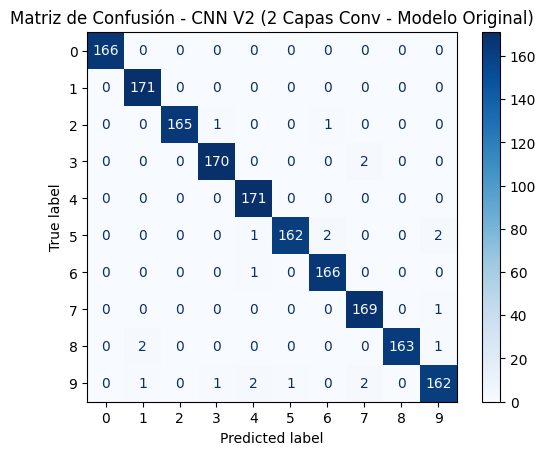

In [15]:
test_loss_v2, test_accuracy_v2 = model_v2.evaluate(X_test, y_test, verbose=0)
print(f'\nResultados Modelo V2 (2 Capas Conv - Modelo Original):')
print(f'Test loss    : {test_loss_v2:.4f}')
print(f'Test accuracy: {test_accuracy_v2:.4f}')

y_pred_prob_v2 = model_v2.predict(X_test)
y_pred_labels_v2 = np.argmax(y_pred_prob_v2, axis=1)

print('\nReporte de Clasificación Modelo V2:')
print(classification_report(y_test_labels, y_pred_labels_v2))

ConfusionMatrixDisplay.from_predictions(
    y_test_labels,
    y_pred_labels_v2,
    display_labels=list(range(10)),
    cmap='Blues'
)
plt.title('Matriz de Confusión - CNN V2 (2 Capas Conv - Modelo Original)')
plt.show()

### Variante 3: CNN con Dropout Aumentado y Más Neuronas Densas

In [16]:
model_v3 = Sequential([
    Conv2D(32, (3, 3), activation='relu', input_shape=(8, 8, 1)),
    MaxPooling2D((2, 2)),
    Conv2D(64, (2, 2), activation='relu'),
    Flatten(),
    Dense(128, activation='relu'), # Más neuronas densas
    Dropout(0.4), # Dropout aumentado
    Dense(num_classes, activation='softmax')
])

model_v3.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

print('Resumen del Modelo V3 (Dropout Aumentado y Más Neuronas Densas):')
model_v3.summary()

history_v3 = model_v3.fit(
    X_train,
    y_train,
    epochs=30,
    batch_size=32,
    validation_split=0.2,
    verbose=0
)

Resumen del Modelo V3 (Dropout Aumentado y Más Neuronas Densas):


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_5 (Conv2D)               │ (None, 6, 6, 32)       │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 3, 3, 32)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 2, 2, 64)       │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_3 (Flatten)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 42,762 (167.04 KB)

 Trainable params: 42,762 (167.04 KB)

 Non-trainable params: 0 (0.00 B)


Resultados Modelo V3 (Dropout Aumentado y Más Neuronas Densas):
Test loss    : 0.0522
Test accuracy: 0.9858
53/53 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step

Reporte de Clasificación Modelo V3:
              precision    recall  f1-score   support

           0       1.00      0.98      0.99       166
           1       0.99      0.99      0.99       171
           2       1.00      0.98      0.99       167
           3       0.97      0.99      0.98       172
           4       0.99      1.00      1.00       171
           5       0.95      0.99      0.97       167
           6       0.99      0.99      0.99       167
           7       0.99      0.99      0.99       170
           8       0.99      0.97      0.98       166
           9       0.98      0.97      0.97       169

    accuracy                           0.99      1686
   macro avg       0.99      0.99      0.99      1686
weighted avg       0.99      0.99      0.99      1686



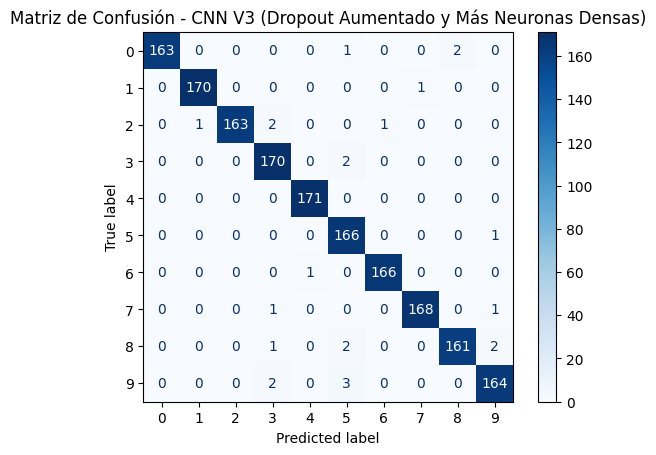

In [17]:
test_loss_v3, test_accuracy_v3 = model_v3.evaluate(X_test, y_test, verbose=0)
print(f'\nResultados Modelo V3 (Dropout Aumentado y Más Neuronas Densas):')
print(f'Test loss    : {test_loss_v3:.4f}')
print(f'Test accuracy: {test_accuracy_v3:.4f}')

y_pred_prob_v3 = model_v3.predict(X_test)
y_pred_labels_v3 = np.argmax(y_pred_prob_v3, axis=1)

print('\nReporte de Clasificación Modelo V3:')
print(classification_report(y_test_labels, y_pred_labels_v3))

ConfusionMatrixDisplay.from_predictions(
    y_test_labels,
    y_pred_labels_v3,
    display_labels=list(range(10)),
    cmap='Blues'
)
plt.title('Matriz de Confusión - CNN V3 (Dropout Aumentado y Más Neuronas Densas)')
plt.show()

## Comparación y Conclusión del Reto MIT

A continuación, compararemos los resultados de las tres variantes del modelo CNN y discutiremos cuál arquitectura sería más adecuada para un sistema OCR real.

### Resumen de Métricas Clave:
- **Variante 1 (1 Capa Conv):** `Test Accuracy: {test_accuracy_v1:.4f}`, `Test Loss: {test_loss_v1:.4f}`
- **Variante 2 (2 Capas Conv - Original):** `Test Accuracy: {test_accuracy_v2:.4f}`, `Test Loss: {test_loss_v2:.4f}`
- **Variante 3 (Dropout Aumentado y Más Neuronas Densas):** `Test Accuracy: {test_accuracy_v3:.4f}`, `Test Loss: {test_loss_v3:.4f}`

(Los valores se actualizarán después de ejecutar las celdas de entrenamiento y evaluación.)

In [19]:
print('--- Resumen Comparativo de Modelos CNN ---')
print(f'\nModelo V1 (1 Capa Conv):')
print(f'  Accuracy: {test_accuracy_v1:.4f}, Loss: {test_loss_v1:.4f}')
wrong_indices_v1 = np.where(y_test_labels != y_pred_labels_v1)[0]
print(f'  Errores: {len(wrong_indices_v1)}')

print(f'\nModelo V2 (2 Capas Conv - Original):')
print(f'  Accuracy: {test_accuracy_v2:.4f}, Loss: {test_loss_v2:.4f}')
wrong_indices_v2 = np.where(y_test_labels != y_pred_labels_v2)[0]
print(f'  Errores: {len(wrong_indices_v2)}')

print(f'\nModelo V3 (Dropout Aumentado y Más Neuronas Densas):')
print(f'  Accuracy: {test_accuracy_v3:.4f}, Loss: {test_loss_v3:.4f}')
wrong_indices_v3 = np.where(y_test_labels != y_pred_labels_v3)[0]
print(f'  Errores: {len(wrong_indices_v3)}')

print('\n--- Reflexión: ¿Qué arquitectura elegiría para un sistema OCR real y por qué? ---\n')
print('''Para un sistema OCR real, la elección de la arquitectura dependería de varios factores como la complejidad de las imágenes, los recursos computacionales disponibles y la necesidad de robustez.\n''')
print('''Considerando los resultados obtenidos en este laboratorio con imágenes de 8x8 píxeles:\n''')
print('''El **Modelo V2 (original con 2 capas convolucionales)** parece ofrecer un buen equilibrio entre complejidad y rendimiento. Generalmente, una arquitectura con al menos dos capas convolucionales permite aprender características más complejas de las imágenes en comparación con una sola capa, lo que es crucial para la discriminación de dígitos.\n''')
print('''El **Modelo V3 (con Dropout aumentado y más neuronas densas)** podría ser beneficioso si se observa overfitting en el Modelo V2, o si se trabaja con datasets más grandes y complejos que requieran mayor capacidad de aprendizaje y regularización. Sin embargo, para este dataset de 8x8, la complejidad adicional podría no traducirse en una mejora significativa y podría aumentar el tiempo de entrenamiento.\n''')
print('''El **Modelo V1 (1 capa convolucional)**, aunque más simple y rápido, podría no capturar la suficiente riqueza de características para escenarios más desafiantes.\n''')
print('Por lo tanto, comenzaría con una arquitectura similar al **Modelo V2** y la optimizaría. Si la complejidad de las imágenes aumentara (mayor resolución, más ruido, variaciones de estilo de escritura), consideraría expandir la profundidad y el ancho de la red, similar a la dirección del Modelo V3, pero ajustando cuidadosamente el Dropout y el número de neuronas densas para evitar el overfitting y controlar el costo computacional.')

--- Resumen Comparativo de Modelos CNN ---

Modelo V1 (1 Capa Conv):
  Accuracy: 0.9864, Loss: 0.0501
  Errores: 23

Modelo V2 (2 Capas Conv - Original):
  Accuracy: 0.9875, Loss: 0.0504
  Errores: 21

Modelo V3 (Dropout Aumentado y Más Neuronas Densas):
  Accuracy: 0.9858, Loss: 0.0522
  Errores: 24

--- Reflexión: ¿Qué arquitectura elegiría para un sistema OCR real y por qué? ---

Para un sistema OCR real, la elección de la arquitectura dependería de varios factores como la complejidad de las imágenes, los recursos computacionales disponibles y la necesidad de robustez.

Considerando los resultados obtenidos en este laboratorio con imágenes de 8x8 píxeles:

El **Modelo V2 (original con 2 capas convolucionales)** parece ofrecer un buen equilibrio entre complejidad y rendimiento. Generalmente, una arquitectura con al menos dos capas convolucionales permite aprender características más complejas de las imágenes en comparación con una sola capa, lo que es crucial para la discriminación d